## MSDS 730 PROJECT
#### Cameron Pykiet

Project overview: 
    
I want to explore usage of GNNs and transformers in determining how well they can fill in missing information when it comes to graph like data. In my work, I deal with validating flight information and there are many instances where there is not enough data to exactly determine locations, but using some intuition such as previous flights and following flight information, the guessing can get narrowed down. I do not have access explicitely to the flight data and much of the time it is hard to get access for free from various sources, so I am going to be using Stanford's 'Amazon Product co-purchasing network' to look at this graph and see how GNNs and transformers can determine the ideal 'co-purchase' as a way to mimic flight-like patterns in this sort of graph. This is more of an exploration into how to use GNNs and transformers and compare how well they work for this kind of problem. 

In this dataset, the graph includes information such as 'if a product i is frequently purchased with product j, the graph contains a directed edge from i to j.' In this case, shows items with lower degrees (how many connections) which are not as commonly co-purchased and items with high degrees get co-purchased more often. 

I am going to be utilizing the libraries networkx and pytorchs torch_geometric to look through this problem and figure out which methods work best. 


Data Citation:
   - J. Leskovec, L. Adamic and B. Adamic. The Dynamics of Viral Marketing. ACM Transactions on the Web (ACM TWEB), 1(1), 2007.

   https://arxiv.org/pdf/2305.14886
   
   https://arxiv.org/pdf/2508.14059
   

In [6]:
## Dataset from https://snap.stanford.edu/data/com-Amazon.html

import networkx as nx

file_path = "Amazon0601.txt"

G = nx.read_edgelist(file_path, comments = '#', nodetype = int, create_using = nx.DiGraph())

print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

print(G)

Average degree: 16.794439183527768
DiGraph with 403394 nodes and 3387388 edges


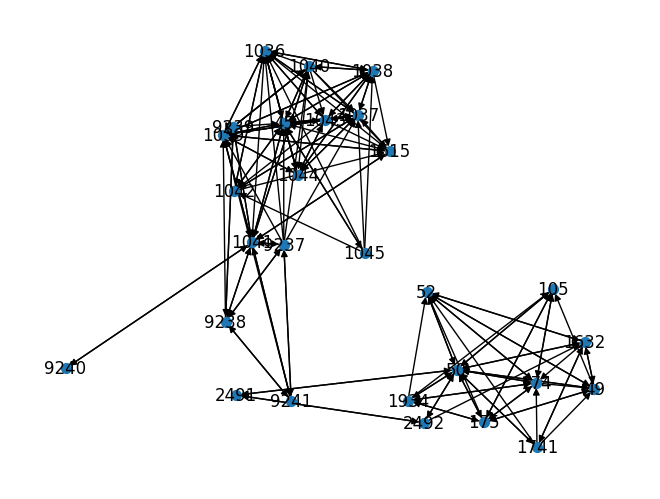

In [7]:
# Visual graph of top 3 degree nodes
import matplotlib.pyplot as plt
degrees = dict(G.degree())

top_3_subgraph = sorted(degrees, key=degrees.get, reverse=True)[:3]
least_3_subgraph = sorted(degrees, key=degrees.get)[:3]

sub_nodes = set(top_3_subgraph)
for node in top_3_subgraph:
    sub_nodes.update(G.neighbors(node))

subgraph = G.subgraph(sub_nodes)
pos = nx.spring_layout(subgraph, k = .75, seed = 42)  
nx.draw(subgraph, pos, with_labels=True, node_size=50, )
plt.show()

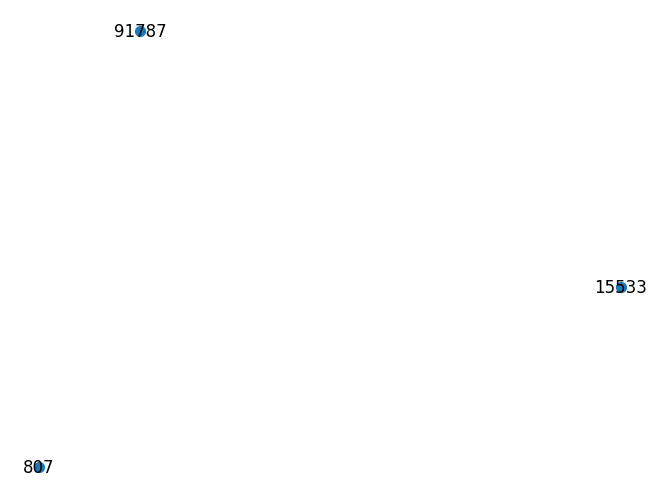

In [8]:
# Visual graph of least 3 degree nodes
sub_nodes = set(least_3_subgraph)

for node in least_3_subgraph:
    sub_nodes.update(G.neighbors(node))

subgraph = G.subgraph(sub_nodes)
pos = nx.spring_layout(subgraph, k = .75, seed = 42)  
nx.draw(subgraph, pos, with_labels=True, node_size=50, )
plt.show()

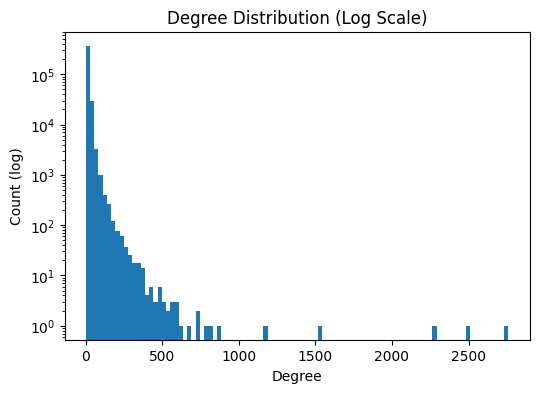

In [9]:
import matplotlib.pyplot as plt

degrees_list = list(degrees.values())

plt.figure(figsize=(6,4))
plt.hist(degrees_list, bins=100, log=True)
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Count (log)")
plt.show()

### Reducing graph size while keeping structure

I decided to create buckets of nodes with certain degrees and gather the proportional amount of them and their neighbors in a smaller dataset to keep overall structure of the graph and make it usable for lesser computational tools. I decided to go up by 100s at a time and keeping the nodes where they were greater than 500 degrees. 

In [10]:
import random

# Get degrees
degrees = dict(G.degree())

# Define buckets
buckets = {
    "0-100": [],
    "101-200": [],
    "201-300": [],
    "301-400": [],
    "401-500": [],
    "500+": []
}

# Assign nodes to buckets
for node, deg in degrees.items():
    if deg <= 100:
        buckets["0-100"].append(node)
    elif deg <= 200:
        buckets["101-200"].append(node)
    elif deg <= 300:
        buckets["201-300"].append(node)
    elif deg <= 400:
        buckets["301-400"].append(node)
    elif deg <= 500:
        buckets["401-500"].append(node)
    else:
        buckets["500+"].append(node)

In [11]:
target_size = 1000

# Total nodes
total_nodes = len(G)

sampled_nodes = []

for bucket_name, nodes in buckets.items():
    if len(nodes) == 0:
        continue
    
    # proportion of this bucket
    proportion = len(nodes) / total_nodes
    
    # number to sample from this bucket
    k = int(proportion * target_size)
    
    # sample (handle small buckets safely)
    k = min(k, len(nodes))
    
    sampled_nodes.extend(random.sample(nodes, k))

In [12]:
sampled_nodes.extend(buckets["500+"])

In [13]:
sampled_nodes = list(set(sampled_nodes))

In [14]:
subG = G.subgraph(sampled_nodes).copy()

In [15]:
expanded_nodes = set(sampled_nodes)

for node in sampled_nodes:
    expanded_nodes.update(G.neighbors(node))

subG = G.subgraph(expanded_nodes).copy()

In [16]:
print("Nodes:", subG.number_of_nodes())
print("Edges:", subG.number_of_edges())
print("Max degree:", max(dict(subG.degree()).values()))

Nodes: 9169
Edges: 46624
Max degree: 74


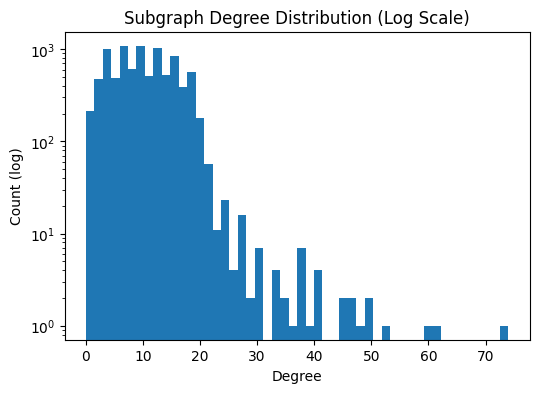

In [17]:
# Visualize the subgraph degree distribution
sub_degrees = dict(subG.degree())
plt.figure(figsize=(6,4))
plt.hist(list(sub_degrees.values()), bins=50, log=True)
plt.title("Subgraph Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Count (log)")
plt.show()


In [18]:
g_over_500 = ([k for k, v in degrees.items() if v > 500])
g_under_500 = ([k for k, v in degrees.items() if v < 500])

print(f"Number of nodes with degree > 500: {len(g_over_500)}")
print(f"Number of nodes with degree < 500: {len(g_under_500)}")




Number of nodes with degree > 500: 22
Number of nodes with degree < 500: 403372


## Creating a simple GNN for link prediction and getting hits@k values

In [26]:
print(subG)
sub_degrees = dict(subG.degree())

DiGraph with 9169 nodes and 46624 edges


In [22]:
# Test for negative samples
count_reverse = 0

for u, v in subG.edges():
    if subG.has_edge(v, u):
        count_reverse += 1

print('Edges: ', subG.number_of_edges())
print(f"Number of edges with reverse edge: {count_reverse}")

Edges:  46624
Number of edges with reverse edge: 33350


In [33]:
# set up stratified sampling for test/train/val split keeping the degree distribution in mind
from sklearn.model_selection import train_test_split

edges = list(subG.edges())

# degrees larger than 1
filtered_edges = [
    (u, v) for u, v in subG.edges() 
    if sub_degrees[u] > 1 and sub_degrees[v] > 1
    ]

def edge_bins(u,v):
    degree_sum = sub_degrees[u] + sub_degrees[v]
    if degree_sum <= 10:
        return '0-10'
    elif degree_sum <= 20:
        return '11-20'
    elif degree_sum <= 30:
        return '21-30'
    else:
        return '31+'
    
edge_degrees = [edge_bins(u,v) for u,v in filtered_edges]


# 70% train, 15% val, 15% test
train_edges, temp_edges, train_degrees, temp_degrees = train_test_split(filtered_edges, edge_degrees, test_size=0.3, stratify=edge_degrees, random_state=42)
val_edges, test_edges, val_degrees, test_degrees = train_test_split(temp_edges, temp_degrees, test_size=0.5, stratify=temp_degrees, random_state=42)

print(f"Train edges: {len(train_edges)}, Val edges: {len(val_edges)}, Test edges: {len(test_edges)}")



Train edges: 32489, Val edges: 6962, Test edges: 6963


## GCN Modeling and Metrics

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import negative_sampling

# ----------------------------
# 1. Node remapping 
# ----------------------------
node_list = list(subG.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}

mapped_train_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in train_edges]

edge_index = torch.tensor(mapped_train_edges, dtype=torch.long).t().contiguous()

# Node features: degree
node_features = torch.tensor(
    [[sub_degrees[node]] for node in node_list],
    dtype=torch.float
)
# Normalize node features
node_features = (node_features/node_features.max()).float()

data = Data(x=node_features, edge_index=edge_index)

# ----------------------------
# 2. GCN encoder
# ----------------------------
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, emb_dim):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, emb_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# ----------------------------
# 3. Edge decoder
# ----------------------------
def decode(z, edge_index):
    src, dst = edge_index
    return (z[src] * z[dst]).sum(dim=1)

# ----------------------------
# 4. Model setup
# ----------------------------
model = GCN(in_channels=1, hidden_channels=16, emb_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

# ----------------------------
# 5. Training loop
# ----------------------------
model.train()
for epoch in range(100):
    optimizer.zero_grad()

    # Node embeddings
    z = model(data.x, data.edge_index)

    # Positive edges = real train edges
    pos_edge_index = data.edge_index

    # Negative edges = sampled non-edges
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    # Scores
    pos_scores = decode(z, pos_edge_index)
    neg_scores = decode(z, neg_edge_index)

    # Labels
    pos_labels = torch.ones(pos_scores.size(0), dtype=torch.float)
    neg_labels = torch.zeros(neg_scores.size(0), dtype=torch.float)

    scores = torch.cat([pos_scores, neg_scores], dim=0)
    labels = torch.cat([pos_labels, neg_labels], dim=0)

    # Loss
    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6904
Epoch 10, Loss: 0.6797
Epoch 20, Loss: 0.6664
Epoch 30, Loss: 0.6470
Epoch 40, Loss: 0.6297
Epoch 50, Loss: 0.6186
Epoch 60, Loss: 0.6127
Epoch 70, Loss: 0.6125
Epoch 80, Loss: 0.6153
Epoch 90, Loss: 0.6150


In [43]:
# Evaluation on validation set
model.eval()
with torch.no_grad():
    z = model(data.x, data.edge_index)

    # Prepare validation edges
    mapped_val_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in val_edges]
    val_edge_index = torch.tensor(mapped_val_edges, dtype=torch.long).t().contiguous()

    # Positive scores
    pos_scores = decode(z, val_edge_index)
    pos_labels = torch.ones(pos_scores.size(0), dtype=torch.float)

    # Negative scores
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=val_edge_index.size(1)
    )
    neg_scores = decode(z, neg_edge_index)
    neg_labels = torch.zeros(neg_scores.size(0), dtype=torch.float)

    # Combine and compute metrics
    scores = torch.cat([pos_scores, neg_scores], dim=0).cpu().numpy()
    labels = torch.cat([pos_labels, neg_labels], dim=0).cpu().numpy()

from sklearn.metrics import roc_auc_score, average_precision_score
auc = roc_auc_score(labels, scores)
ap = average_precision_score(labels, scores)
print(f"Validation AUC: {auc:.4f}, AP: {ap:.4f}")


Validation AUC: 0.6965, AP: 0.6851


In [52]:
import torch
import random

def edge_score(z, src, dst):
    return (z[src] * z[dst]).sum(dim=1)

def hits_at_k_sampled(z, pos_edge_index, num_nodes, k=10, num_neg=100):
    src_all, dst_all = pos_edge_index
    hits = 0
    total = src_all.size(0)

    # make lookup of existing positive edges to avoid sampling true edges as negatives
    pos_edge_set = set((int(s), int(d)) for s, d in zip(src_all.tolist(), dst_all.tolist()))

    for i in range(total):
        src = int(src_all[i])
        true_dst = int(dst_all[i])

        neg_dsts = set()
        while len(neg_dsts) < num_neg:
            cand = random.randint(0, num_nodes - 1)
            if cand != true_dst and (src, cand) not in pos_edge_set:
                neg_dsts.add(cand)

        neg_dsts = list(neg_dsts)

        # build candidate list: true edge + negatives
        cand_src = torch.tensor([src] * (1 + num_neg), dtype=torch.long, device=z.device)
        cand_dst = torch.tensor([true_dst] + neg_dsts, dtype=torch.long, device=z.device)

        scores = edge_score(z, cand_src, cand_dst)

        # true edge is first entry
        topk_idx = torch.topk(scores, k=min(k, len(scores))).indices
        if 0 in topk_idx:
            hits += 1

    return hits / total

mapped_val_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in val_edges]
val_edge_index = torch.tensor(mapped_val_edges, dtype=torch.long).t().contiguous()

model.eval()
with torch.no_grad():
    z = model(data.x, data.edge_index)

for k in [1, 5, 10, 20]:
    h = hits_at_k_sampled(z, val_edge_index, num_nodes=data.num_nodes, k=k, num_neg=100)
    print(f"Hits@{k}: {h:.4f}")


Hits@1: 0.0901
Hits@5: 0.1537
Hits@10: 0.2287
Hits@20: 0.3806


GraphSAGE (Graph Sample and Aggregate) Modeling and Metrics
* Samples Neighbors 
* Aggregate information
* Builds node embeddings efficiently

In [55]:
# GraphSAGE 
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, emb_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, emb_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv2(x, edge_index)
        return x
    
model_sage = GraphSAGE(in_channels=1, hidden_channels=32, emb_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

# ----------------------------
# 5. Training loop
# ----------------------------
model_sage.train()
for epoch in range(100):
    optimizer.zero_grad()

    # Node embeddings
    z = model(data.x, data.edge_index)

    # Positive edges = real train edges
    pos_edge_index = data.edge_index

    # Negative edges = sampled non-edges
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    # Scores
    pos_scores = decode(z, pos_edge_index)
    neg_scores = decode(z, neg_edge_index)

    # Labels
    pos_labels = torch.ones(pos_scores.size(0), dtype=torch.float)
    neg_labels = torch.zeros(neg_scores.size(0), dtype=torch.float)

    scores = torch.cat([pos_scores, neg_scores], dim=0)
    labels = torch.cat([pos_labels, neg_labels], dim=0)

    # Loss
    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6105
Epoch 10, Loss: 0.6134
Epoch 20, Loss: 0.6120
Epoch 30, Loss: 0.6124
Epoch 40, Loss: 0.6136
Epoch 50, Loss: 0.6103
Epoch 60, Loss: 0.6113
Epoch 70, Loss: 0.6109
Epoch 80, Loss: 0.6128
Epoch 90, Loss: 0.6105


In [54]:
import torch
import random

def edge_score(z, src, dst):
    return (z[src] * z[dst]).sum(dim=1)

def hits_at_k_sampled(z, pos_edge_index, num_nodes, k=10, num_neg=100):
    src_all, dst_all = pos_edge_index
    hits = 0
    total = src_all.size(0)

    # make lookup of existing positive edges to avoid sampling true edges as negatives
    pos_edge_set = set((int(s), int(d)) for s, d in zip(src_all.tolist(), dst_all.tolist()))

    for i in range(total):
        src = int(src_all[i])
        true_dst = int(dst_all[i])

        neg_dsts = set()
        while len(neg_dsts) < num_neg:
            cand = random.randint(0, num_nodes - 1)
            if cand != true_dst and (src, cand) not in pos_edge_set:
                neg_dsts.add(cand)

        neg_dsts = list(neg_dsts)

        # build candidate list: true edge + negatives
        cand_src = torch.tensor([src] * (1 + num_neg), dtype=torch.long, device=z.device)
        cand_dst = torch.tensor([true_dst] + neg_dsts, dtype=torch.long, device=z.device)

        scores = edge_score(z, cand_src, cand_dst)

        # true edge is first entry
        topk_idx = torch.topk(scores, k=min(k, len(scores))).indices
        if 0 in topk_idx:
            hits += 1

    return hits / total

mapped_val_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in val_edges]
val_edge_index = torch.tensor(mapped_val_edges, dtype=torch.long).t().contiguous()

model_sage.eval()
with torch.no_grad():
    z = model_sage(data.x, data.edge_index)

for k in [1, 5, 10, 20]:
    h = hits_at_k_sampled(z, val_edge_index, num_nodes=data.num_nodes, k=k, num_neg=100)
    print(f"Hits@{k}: {h:.4f}")


Hits@1: 0.0026
Hits@5: 0.0195
Hits@10: 0.0435
Hits@20: 0.0982


## Graph Transformer Models and Metrics

In [56]:
from torch_geometric.nn import TransformerConv
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, emb_dim, heads = 2):
        super().__init__()
        self.conv1 = GATConv(
            in_channels, 
            hidden_channels, 
            heads = heads,
            dropout = 0.1)
        self.conv2 = GATConv(
            hidden_channels * heads, 
            emb_dim, 
            heads=1, 
            concat = False,
            dropout = 0.1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv2(x, edge_index)
        return x
    
model_gat = GAT(in_channels=1, hidden_channels=32, emb_dim=16, heads=2)

optimizer = torch.optim.Adam(model_gat.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

# ----------------------------
# 5. Training loop

model_gat.train()
for epoch in range(100):
    optimizer.zero_grad()

    # Node embeddings
    z = model(data.x, data.edge_index)

    # Positive edges = real train edges
    pos_edge_index = data.edge_index

    # Negative edges = sampled non-edges
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    # Scores
    pos_scores = decode(z, pos_edge_index)
    neg_scores = decode(z, neg_edge_index)

    # Labels
    pos_labels = torch.ones(pos_scores.size(0), dtype=torch.float)
    neg_labels = torch.zeros(neg_scores.size(0), dtype=torch.float)

    scores = torch.cat([pos_scores, neg_scores], dim=0)
    labels = torch.cat([pos_labels, neg_labels], dim=0)

    # Loss
    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6111
Epoch 10, Loss: 0.6100
Epoch 20, Loss: 0.6095
Epoch 30, Loss: 0.6135
Epoch 40, Loss: 0.6129
Epoch 50, Loss: 0.6127
Epoch 60, Loss: 0.6117
Epoch 70, Loss: 0.6119
Epoch 80, Loss: 0.6104
Epoch 90, Loss: 0.6100


In [57]:
model_gat.eval()
with torch.no_grad():
    z = model_gat(data.x, data.edge_index)

for k in [1, 5, 10, 20]:
    h = hits_at_k_sampled(z, val_edge_index, num_nodes=data.num_nodes, k=k, num_neg=100)
    print(f"Hits@{k}: {h:.4f}")

Hits@1: 0.0175
Hits@5: 0.0916
Hits@10: 0.1725
Hits@20: 0.3143


### TransformerConv model

In [59]:
# TransformerConv
from torch_geometric.nn import TransformerConv
import torch.nn.functional as F

class GraphTransformer(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, emb_dim, heads=2):
        super().__init__()
        self.conv1 = TransformerConv(
            in_channels, 
            hidden_channels, 
            heads=heads,
            dropout=0.1)
        self.conv2 = TransformerConv(
            hidden_channels * heads, 
            emb_dim, 
            heads=1, 
            concat=False,
            dropout=0.1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model_transformer = GraphTransformer(in_channels=1, hidden_channels=32, emb_dim=16, heads=2)
optimizer = torch.optim.Adam(model_transformer.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

model_transformer.train()
for epoch in range(100):
    optimizer.zero_grad()

    # Node embeddings
    z = model(data.x, data.edge_index)

    # Positive edges = real train edges
    pos_edge_index = data.edge_index

    # Negative edges = sampled non-edges
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge_index.size(1)
    )

    # Scores
    pos_scores = decode(z, pos_edge_index)
    neg_scores = decode(z, neg_edge_index)

    # Labels
    pos_labels = torch.ones(pos_scores.size(0), dtype=torch.float)
    neg_labels = torch.zeros(neg_scores.size(0), dtype=torch.float)

    scores = torch.cat([pos_scores, neg_scores], dim=0)
    labels = torch.cat([pos_labels, neg_labels], dim=0)

    # Loss
    loss = criterion(scores, labels)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

model_gat.eval()
with torch.no_grad():
    z = model_gat(data.x, data.edge_index)

for k in [1, 5, 10, 20]:
    h = hits_at_k_sampled(z, val_edge_index, num_nodes=data.num_nodes, k=k, num_neg=100)
    print(f"Hits@{k}: {h:.4f}")

Epoch 0, Loss: 0.6120
Epoch 10, Loss: 0.6107
Epoch 20, Loss: 0.6106
Epoch 30, Loss: 0.6097
Epoch 40, Loss: 0.6105
Epoch 50, Loss: 0.6109
Epoch 60, Loss: 0.6111
Epoch 70, Loss: 0.6095
Epoch 80, Loss: 0.6117
Epoch 90, Loss: 0.6111
Hits@1: 0.0191
Hits@5: 0.0921
Hits@10: 0.1706
Hits@20: 0.3166
